In [ ]:
!pip install torch==2.3.1 torchtext==0.18.0 matplotlib

  Using cached torch-2.3.1-cp312-cp312-manylinux1_x86_64.whl.metadata (26 kB)
  Using cached torchtext-0.18.0-cp312-cp312-manylinux1_x86_64.whl.metadata (7.9 kB)
Using cached torch-2.3.1-cp312-cp312-manylinux1_x86_64.whl (779.1 MB)
Using cached torchtext-0.18.0-cp312-cp312-manylinux1_x86_64.whl (2.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fastai 2.8.7 requires torchvision>=0.11, which is not installed.
timm 1.0.27 requires torchvision, which is not installed.


In [ ]:
!pip install torchdata==0.7.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.4/184.4 kB 5.8 MB/s eta 0:00:00
  Attempting uninstall: torchdata
    Found existing installation: torchdata 0.11.0
    Uninstalling torchdata-0.11.0:
      Successfully uninstalled torchdata-0.11.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchtune 0.6.1 requires torchdata==0.11.0, but you have torchdata 0.7.1 which is incompatible.


In [ ]:
import torch
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
from torch import nn
from torchtext import datasets
from torch.utils.data import random_split


/usr/local/lib/python3.12/dist-packages/torchtext/datasets/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/usr/local/lib/python3.12/dist-packages/torchtext/data/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)


In [ ]:
!pip install portalocker==2.7.0

  Attempting uninstall: portalocker
    Found existing installation: portalocker 3.2.0
    Uninstalling portalocker-3.2.0:
      Successfully uninstalled portalocker-3.2.0


In [ ]:
from torchtext.datasets import AG_NEWS
from torchtext.data import to_map_style_dataset

train_set = AG_NEWS(split="train")
train_iter = iter(train_set)
train_set_map = to_map_style_dataset(train_set)

test_set = AG_NEWS(split="test")
test_iter = iter(test_set)
test_set_map = to_map_style_dataset(test_set)

In [ ]:
#DATASET SIZES
print(f"Training set size: {len(train_set_map)}")
print(f"Test set size: {len(test_set_map)}")
labels_set = {label for label, text in train_set_map}
print(f"The set of unique labels: {labels_set}")

Training set size: 120000
Test set size: 7600
The set of unique labels: {1, 2, 3, 4}


In [ ]:
labels_list=[label for label, text in train_set_map]
labels_tensor=torch.tensor(labels_list)

In [ ]:
#count the frequency of each label
unique_labels, count=torch.unique(labels_tensor, return_counts=True)
label_dict={1:"world", 2:"Sports", 3:"Bussiness", 4:"Science & Technology"}
#printing some samples for each label
print_sample_size = 2
for label in unique_labels:
  count=0
  print(f"Some samples with label {label}, corresponding to category \"{label_dict[int(label)]}\"")
  for l, t in train_set_map:
      if l == label:
          print(t)
          count += 1
          print(" ")
          if count >= print_sample_size:
              break
  print("-------------------------------------------------------")

Some samples with label 1, corresponding to category "world"
Venezuelans Vote Early in Referendum on Chavez Rule (Reuters) Reuters - Venezuelans turned out early\and in large numbers on Sunday to vote in a historic referendum\that will either remove left-wing President Hugo Chavez from\office or give him a new mandate to govern for the next two\years.
 
S.Koreans Clash with Police on Iraq Troop Dispatch (Reuters) Reuters - South Korean police used water cannon in\central Seoul Sunday to disperse at least 7,000 protesters\urging the government to reverse a controversial decision to\send more troops to Iraq.
 
-------------------------------------------------------
Some samples with label 2, corresponding to category "Sports"
Phelps, Thorpe Advance in 200 Freestyle (AP) AP - Michael Phelps took care of qualifying for the Olympic 200-meter freestyle semifinals Sunday, and then found out he had been added to the American team for the evening's 400 freestyle relay final. Phelps' rivals Ian 

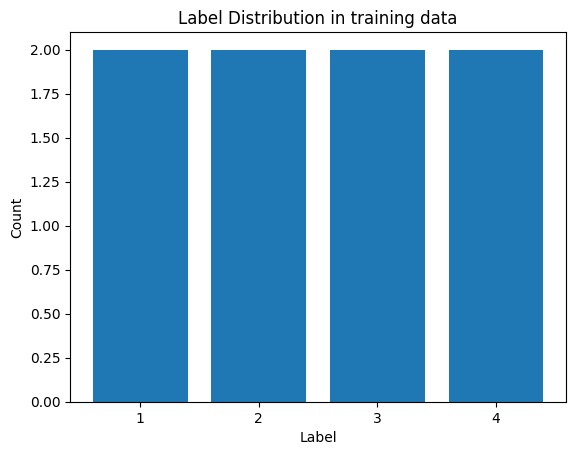

In [ ]:
#plotting the histogram for label distribution
plt.bar(unique_labels, count,tick_label=list(range(1,5)))
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Label Distribution in training data")
plt.show()